<a href="https://colab.research.google.com/github/HandyLukita1/BNCC-ML-LnT/blob/main/BNCC_LnT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### EDA (Explolatory Data Analysis)

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


# Pengaturan Untuk Visualisasi
sns.set_theme(style='whitegrid')
plt.figure(figsize=(6,4))

# 1. Memuat Dataset
df = pd.read_csv('estimation_of_obesity_levels_based_on_habits.csv (1).csv')
# Membersihkan baris yang kosong
df_clean = df.dropna(subset=['NObeyesdad']).copy()

print(f'Jumlah Total baris data valid: {df_clean.shape[0]}')
print(f'Jumlah Fitur: {df_clean.shape[1]}')

Jumlah Total baris data valid: 1900
Jumlah Fitur: 17


<Figure size 600x400 with 0 Axes>

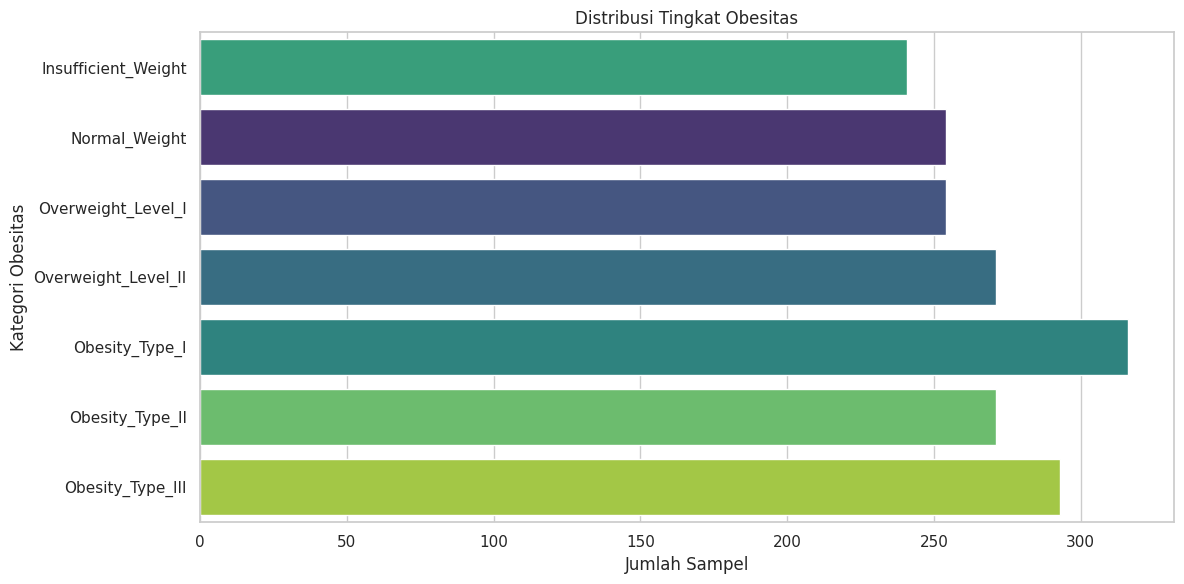

In [2]:
# 2. Analisis Distribusi Kelas
# membuat countplot untuk menghitung jumlah frekuensi dan persentase sampel pada
# kategori obesitas (NObeyesdad)
plt.figure(figsize=(12,6))
order_classes = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

ax = sns.countplot(
    data=df_clean,
    y='NObeyesdad',
    order=order_classes,
    hue='NObeyesdad',
    palette='viridis',
    legend=False,
)

plt.title('Distribusi Tingkat Obesitas')
plt.xlabel('Jumlah Sampel')
plt.ylabel('Kategori Obesitas')

plt.tight_layout()
plt.show()

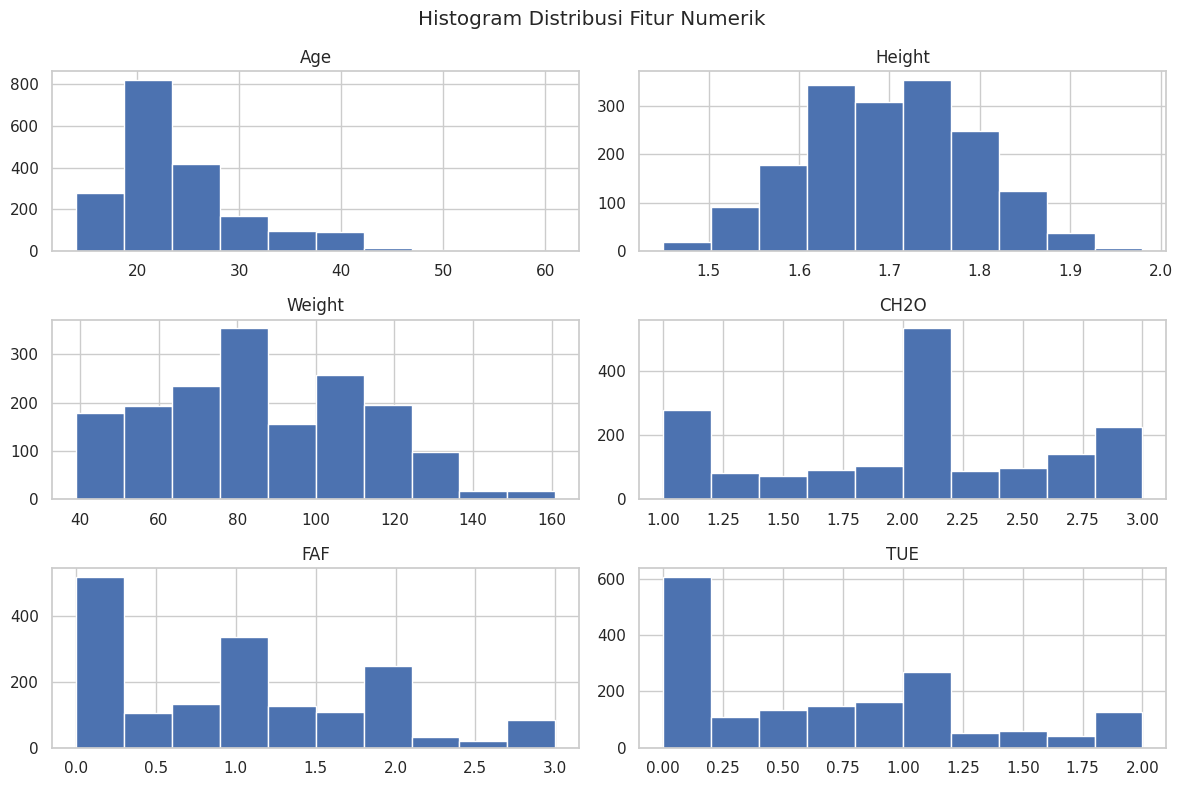

In [3]:
# 3. Analisis Distribusi Numerik
# membuat statistik dan histogram untuk numerik untuk age, height, weight, ch2o, faf
numerical_column = ['Age', 'Height', 'Weight', 'CH2O', 'FAF', 'TUE']
df_clean[numerical_column].hist(figsize=(12,8))
plt.suptitle('Histogram Distribusi Fitur Numerik')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6671/3962066398.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


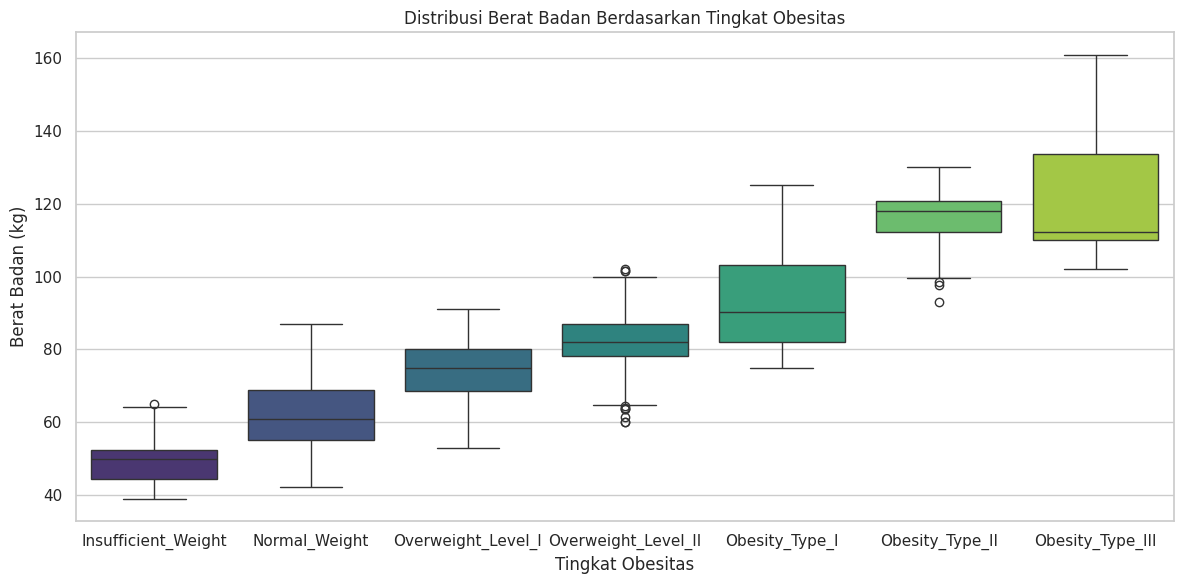

In [4]:
# 4. Menganalisis Sebaran Berat Badan Terhadap Obesitas
# melihat hubungan antara berat badan (Weight) dengan kategori tingkat obesitas menggunakan boxplot
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_clean,
    x='NObeyesdad',
    y='Weight',
    order=order_classes,
    palette='viridis',
)
plt.title('Distribusi Berat Badan Berdasarkan Tingkat Obesitas')
plt.xlabel('Tingkat Obesitas')
plt.ylabel('Berat Badan (kg)')
plt.tight_layout()
plt.show()

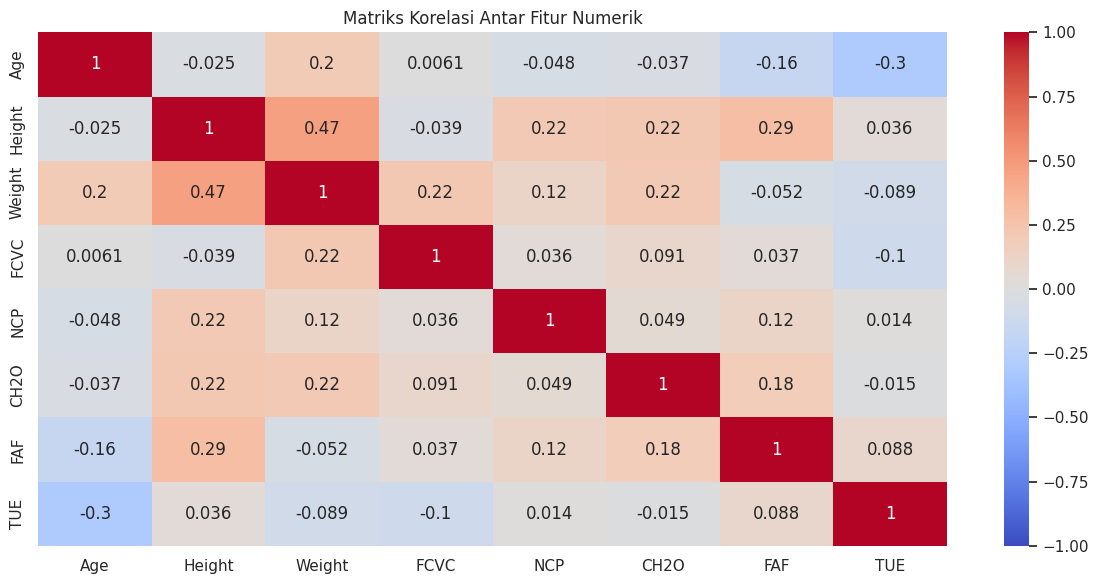

In [5]:
# 5. Analisis Korelasi pada Fitur Numerik
# Menghitung Koefisien korelasi pearson (r) antar fitur numerik dan menampilkannya di heatmap matriks
plt.figure(figsize=(12,6))
numeric_df = df_clean.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
)
plt.title('Matriks Korelasi Antar Fitur Numerik')
plt.tight_layout()
plt.show()

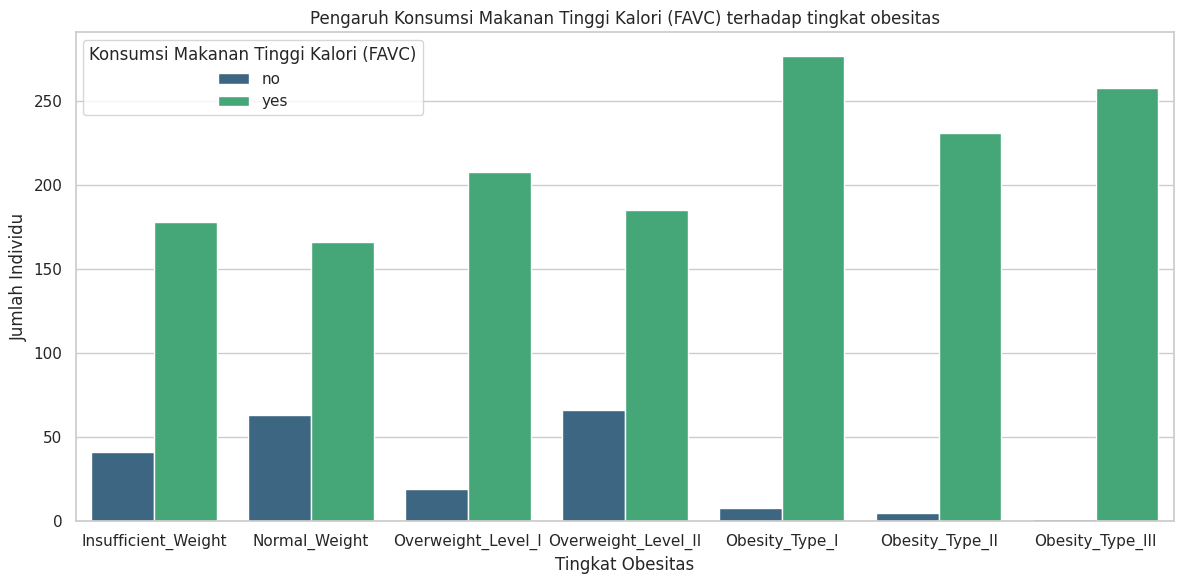

In [6]:
# 6. Analisis Adanya Kalori Tinggi vs Obesitas
# Membuat countplot dengan hue untuk membandingkan frekuensi konsumsi makanan tinggi kalori (FAVC) pada
# setiap tingkat obesitas
plt.figure(figsize=(12,6))
sns.countplot(
    data=df_clean,
    x='NObeyesdad',
    hue='FAVC',
    palette='viridis',
    order=order_classes,
)
plt.title('Pengaruh Konsumsi Makanan Tinggi Kalori (FAVC) terhadap tingkat obesitas')
plt.xlabel('Tingkat Obesitas')
plt.ylabel('Jumlah Individu')
plt.legend(title='Konsumsi Makanan Tinggi Kalori (FAVC)')
plt.tight_layout()
plt.show()

2. Data Preprocessing and Scikit-Learn Pipeline

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# memisahkan Fitur (X) dan Target (y)
X = df_clean.drop(columns=['NObeyesdad'])
y = df_clean['NObeyesdad']

# membagi Data Latih dan Data Uji (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# mendefinisikan kolom numerik berserta kategorinya
numeric_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
categorical_features = [
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC',
    'MTRANS',
]

# membuat ColumnTransformer untuk standarisasi dan encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

3. Model Engineering & Selection


In [8]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# 1. Data harus bersih dari nilai NaN sebelum masuk pemodelan
df_clean_model = df_clean.dropna().copy()
X = df_clean_model.drop(columns=['NObeyesdad'])
y = df_clean_model['NObeyesdad']

# split ulang data train dan test agar ukurannya sama dengan DataFrame
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Mendefinisikan Tiga Model yang Diuji
models = {
    'Baseline (KNN)': KNeighborsClassifier(n_neighbors = 5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),

}

# 3. Melakukan training dan evaluasi dengan menggunakan loop
results = {}
print('Hasil Eksperimen Kinerja Model')
for name, model in models.items():

  # merangkai pipeline preprocessor dan juga model klasifikasi
  full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('classifier', model),])

  # melatih Model dengan data training
  full_pipeline.fit(X_train, y_train)

  # memprediksi Data Testing
  y_pred = full_pipeline.predict(X_test)

  # menghitung Akurasi
  acc = accuracy_score(y_test, y_pred)
  results[name] = acc

  print(f'\nModel: {name}')
  print(f'Akurasi: {acc * 100:.2f}%')
  print('-' * 40)

# 4. Menentukan Model terbaik berdasarkan akurasi
best_model_name = max(results, key=results.get)
print(f'\nKesimpulan: Model terbaik yang dipilih adalah: {best_model_name}')

Hasil Eksperimen Kinerja Model

Model: Baseline (KNN)
Akurasi: 67.82%
----------------------------------------

Model: Random Forest
Akurasi: 80.46%
----------------------------------------

Model: Gradient Boosting
Akurasi: 90.80%
----------------------------------------

Kesimpulan: Model terbaik yang dipilih adalah: Gradient Boosting


4. Validasi & Hyperparameter Tuning

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import joblib

# Memilih Random Forest sebagai model terbaik untuk dituning
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42)),
    ]
)

# Konfigurasi Grid Search Parameter
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
}

# Melakukan GridSearchCV dengan 5-Fold Cross Validation atau 5 data dapat diuji secara bergantian
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

# Mengambil estimator terbaik hasil tuning
best_rf_model = grid_search.best_estimator_
print(f'Skor Cross-Validation Terbaik: {grid_search.best_score_ * 100:.2f}%')
print(f'Parameter Optimal: {grid_search.best_params_}')

# Menyimpan model final lengkap beserta pipeline ke file .pkl
joblib.dump(best_rf_model, 'model_obesitas_terbaik.pkl')
print("Model berhasil disimpan ke dalam file 'model_obesitas_terbaik.pkl'")

Skor Cross-Validation Terbaik: 85.34%
Parameter Optimal: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Model berhasil disimpan ke dalam file 'model_obesitas_terbaik.pkl'


5. Evaluasi

Laporan Klasifikasi Model Terbaik
                     precision    recall  f1-score   support

Insufficient_Weight       0.91      0.91      0.91        11
      Normal_Weight       0.54      0.54      0.54        13
     Obesity_Type_I       0.84      1.00      0.91        16
    Obesity_Type_II       1.00      0.86      0.92         7
   Obesity_Type_III       1.00      1.00      1.00        21
 Overweight_Level_I       0.55      0.60      0.57        10
Overweight_Level_II       0.83      0.56      0.67         9

           accuracy                           0.82        87
          macro avg       0.81      0.78      0.79        87
       weighted avg       0.82      0.82      0.81        87



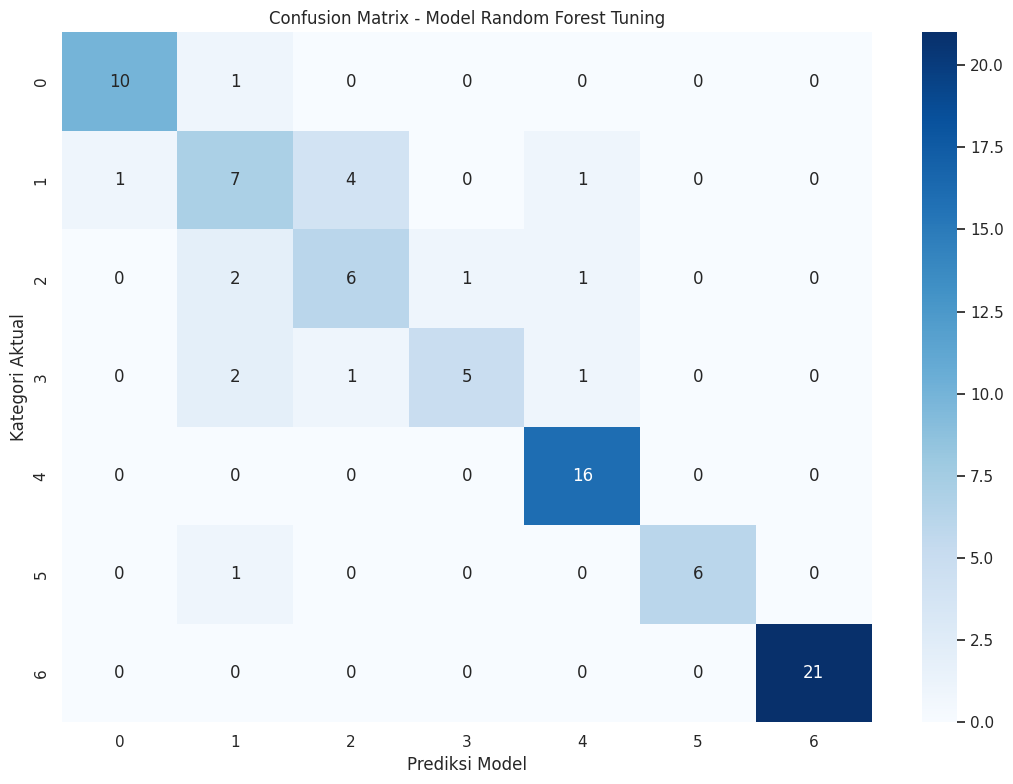

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Melakukan Prediksi pada Data Uji menggunakan model terbaik
y_pred_best = best_rf_model.predict(X_test)

# 2. Menampilkan Klasifikasi Lengkap seperti yang ada di tugas yaitu Accuracy, Precision, Recall, dan F1-Score
print('Laporan Klasifikasi Model Terbaik')
print(classification_report(y_test, y_pred_best))

# 3. Membuat Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best, labels=order_classes)

plt.figure(figsize=(11,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
)

plt.title('Confusion Matrix - Model Random Forest Tuning')
plt.xlabel('Prediksi Model')
plt.ylabel('Kategori Aktual')
plt.tight_layout()
plt.show()

6. Model Deployment


In [11]:
%%writefile app.py
import joblib
import pandas as pd
import streamlit as st

# 1. Memuat model terbaik (.pkl) yang akan di training
model = joblib.load('model_obesitas_terbaik.pkl')

# Konfigurasi Halaman Web
st.title('Sistem Peringatan Dini Resiko Obesitas (Puskesmas)')
st.write(
    'Aplikasi berbasis AI ini dirancang untuk membantu tenaga medis puskesmas'
    'dalam memprediksi tingkat kategori obesitas pasien berdsarkan ukuran tubuh '
    'dan kebiasaan gaya hidup'
)

# 2. Membuat Formulir Input Data Pasien
with st.form('form_obesitas'):
  st.subheader('Masukkan Data & Kebiasaan Pasien')

  col1, col2 = st.columns(2)
  with col1:
    age = st.number_input('Umur', min_value = 1, max_value = 120, value = 22)
    gender = st.selectbox('Jenis Kelamin', ['Female','Male'])
    height = st.number_input('Tinggi Badan', min_value=1.0, max_value=2.5, value=1.7)
    weight = st.number_input('Berat Badan', min_value=10, max_value = 300, value = 70)
    family_history = st.selectbox('Riwayat Obesitas dalam Keluarga?', ['yes', 'no'])
    favc = st.selectbox('Sering Mengonsumsi Makanan Tinggi Kalori', ['yes', 'no'])
    faf = st.slider('Frekuensi Olahraga per Minggu (0-3)',min_value=0,max_value=3,value=1)

    submit_button = st.form_submit_button('Prediksi Risiko')

# 3. Proses Hasil Prediksi
if submit_button:
  input_data = pd.DataFrame({
      'Gender': [gender],
      'Age': [age],
      'Height': [height],
      'Weight': [weight],
      'family_history_with_overweight': [family_history],
      'FAVC': [favc],
      'FCVC': [2.0],
      'NCP': [3.0],
      'CAEC': ['Sometimes'],
      'SMOKE': ['no'],
      'CH2O': [2.0],
      'SCC': ['no'],
      'FAF': [faf],
      'TUE': [1.0],
      'CALC': ['Sometimes'],
      'MTRANS': ['Public_Transportation'],
  })

  # Prediksi Menggunakan Model
  hasil = model.predict(input_data) [0]

  st.markdown('----')
  st.subheader('Hasil Diagnosis Sistem:')

  if 'Normal' in hasil:
    st.success(f'Hasil Normal: Pasien berada dalam kategori {hasil}.'
    ' Pertahankan pola hidup sehat!')
  elif 'Insufficient' in hasil:
    st.warning(f'Perhatian: Pasien terdeteksi {hasil} (Kekurangan berat'
        ' badan). Perlu peningkatan gizi seimbang.')
  elif 'Overweight' in hasil:
    st.error(f'Peringatan Dini:Pasien terdeteksi {hasil}. Disarankan'
        ' untuk mulai mengatur pola makan dan aktivitas fisik.'
    )
  else: # Untuk Obesity type I, II dan III
    st.error(f'Risiko Tinggi:Pasien terdeteksi masuk dalam kategori'
        f'{hasil}. Segera lakukan konseling kesehatan di Puskesmas!')





Writing app.py


In [12]:
%%writefile requirements.txt
streamlit
pandas
joblib
scikit-learn==1.6.1

Writing requirements.txt
